# Global eSSVI vs SSVI vs raw SVI — benchmark

Three ways to build a volatility surface, fitted to the **same live Deribit chain** and
compared on the trade-off that actually distinguishes them: **how well they fit** against
**whether the result is free of arbitrage**.

| | parameters | arbitrage guarantee |
|---|---|---|
| **raw SVI** (`svi.py`) | 5 per expiry, fitted independently | none — each slice is checked *after* the fact, and nothing couples adjacent expiries |
| **SSVI** (`ssvi.py`) | 1 per expiry (θ) + ~3 global (ρ, shape) | surface-wide (Gatheral–Jacquier Cor. 4.1), but **one ρ for every maturity** |
| **Global eSSVI** (`global_essvi.py`) | 3 per expiry (θ, ρ, ψ) | surface-wide **by construction** (Mingone Prop. 3.1), with ρ free to vary by maturity |

eSSVI is the middle term: it relaxes SSVI's single ρ without giving up the global
guarantee. The claim this notebook tests is that it lands close to unconstrained SVI on fit
quality while remaining, unlike SVI, incapable of producing arbitrage.

The mechanism is worth stating up front, because it is what makes the arbitrage column
different in kind rather than degree. SVI and SSVI are fitted and then *checked*; eSSVI is
fitted over a reparametrized box (`unbox`) every point of which maps to an admissible
surface, so there is no failure mode to check for. `check_no_arbitrage` is run here as a
test of the implementation, not as a gate.

In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import data
import svi
import ssvi
import surface
import arbitrage as arb
import global_essvi as ge

%matplotlib inline
warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.width', 160)

PALETTE = {'SVI': 'C3', 'SSVI': 'C0', 'eSSVI': 'C2', 'market': '0.25'}
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

## 1 — One chain, three models

All three models are fitted to exactly the same quotes, so any difference is the model and
not the data. The chain is filtered to **OTM options only** (`ge.filter_chain`): Deribit
lists both a call and a put at every strike, and the ITM half is nearly all intrinsic
value — negligible vega, an ill-conditioned implied-vol inversion, and (in a price-space
objective) six-figure prices that swamp the sum of squares while saying almost nothing
about the smile.

In [2]:
CURRENCY, MAX_T = 'BTC', 1.5

raw = data.fetch_book_summary(CURRENCY)
chain = ge.filter_chain(data.build_chain(raw), max_T=MAX_T)

K   = chain['strike'].to_numpy(float)
T   = chain['T'].to_numpy(float)
F   = chain['forward'].to_numpy(float)
MKT = chain['mid_iv'].to_numpy(float)
k   = np.log(K / F)
EXPIRIES = np.array(sorted(chain['T'].unique()))

# half the bid-ask, converted to vol points: the precision the market itself quotes to,
# and the only honest yardstick for "is this fitted well enough"
HALF_SPREAD_VOL = 0.5 * (chain['ask'].to_numpy(float) - chain['bid'].to_numpy(float)) \
                  / np.maximum(bs.vega(F, K, T, 0.0, 0.0, MKT), 1e-9)

print(f'{len(chain)} OTM quotes across {len(EXPIRIES)} expiries, T in '
      f'[{T.min():.4f}, {T.max():.4f}]y, forward ~{F[0]:,.0f}')
print(f'median half bid-ask = {np.median(HALF_SPREAD_VOL):.3%} of vol')
chain.head()

185 OTM quotes across 7 expiries, T in [0.0302, 0.8548]y, forward ~63,584
median half bid-ask = 0.386% of vol


,strike,expiry,T,forward,mid_iv,weight,option_type,bid,ask,mid
0,56000.0,2026-08-28 08:00:00+00:00,0.030166,63583.55,0.398634,0.024735,P,50.86684,57.225195,54.046018
1,57000.0,2026-08-28 08:00:00+00:00,0.030166,63583.55,0.378773,0.024735,P,76.30026,82.658615,79.479437
2,58000.0,2026-08-28 08:00:00+00:00,0.030166,63583.55,0.352114,0.006184,P,101.73368,114.450390,108.092035
3,59000.0,2026-08-28 08:00:00+00:00,0.030166,63583.80,0.332301,0.002748,P,152.60112,171.676260,162.138690
4,60000.0,2026-08-28 08:00:00+00:00,0.030166,63583.55,0.312607,0.000989,P,228.90078,260.692555,244.796668


In [3]:
timings = {}

t0 = time.perf_counter()
svi_surface = surface.fit_surface(chain, validate=False, check_interior=False)
timings['SVI'] = time.perf_counter() - t0

t0 = time.perf_counter()
ssvi_surface = surface.fit_ssvi_surface(chain, validate=False)
timings['SSVI'] = time.perf_counter() - t0

t0 = time.perf_counter()
essvi_result = ge.calibrate(**ge.chain_to_calibration_inputs(chain))
timings['eSSVI'] = time.perf_counter() - t0
essvi_surface = essvi_result.surface

N = len(EXPIRIES)
N_PARAMS = {'SVI': 5 * N, 'SSVI': N + 3, 'eSSVI': 3 * N}
SURFACES = {'SVI': svi_surface, 'SSVI': ssvi_surface, 'eSSVI': essvi_surface}

for name in SURFACES:
    print(f'{name:6s} {N_PARAMS[name]:3d} params   fitted in {timings[name]:.2f}s')
print(f'\neSSVI converged: {essvi_result.success} ({essvi_result.opt_result.message})')

SVI     35 params   fitted in 0.32s
SSVI    10 params   fitted in 0.24s
eSSVI   21 params   fitted in 0.11s

eSSVI converged: True (`ftol` termination condition is satisfied.)


`fit_surface` is called with `validate=False` deliberately. Its default is to *raise* on a
slice that fails the butterfly check, or with `on_bad_slice="skip"` to drop it — either
way the surface you get back is not the surface the optimizer actually produced. Section 3
is about what the fit produces, so the validation is disabled here and applied explicitly
instead.

In [4]:
def forward_at(s, t):
    """Log-linear forward curve, uniform across the three surface types."""
    if isinstance(s, ge.GlobalESSVISurface):
        return s.forward_at(t)
    return float(np.exp(np.interp(t, s.maturities, np.log(s.forwards))))


def model_iv(s, strikes, maturity):
    return np.asarray(s.implied_vol(strikes, maturity), dtype=float)


def total_variance(s, k_grid, t):
    """w(k,t) queried through the public implied_vol interface only, so the three
    models are probed identically and nothing internal to one leaks into the test."""
    return model_iv(s, forward_at(s, t) * np.exp(k_grid), t) ** 2 * t


def g_numerical(k_grid, w):
    """Gatheral-Jacquier g(k) by finite differences. g < 0 <=> negative implied
    density <=> butterfly arbitrage. Model-agnostic: it needs only w on a grid."""
    dw = np.gradient(w, k_grid)
    d2w = np.gradient(dw, k_grid)
    return (1 - k_grid * dw / (2 * w)) ** 2 - (dw ** 2 / 4) * (1 / w + 0.25) + d2w / 2


def fit_errors(s):
    fitted = np.array([float(s.implied_vol(K[i], T[i])) for i in range(len(K))])
    return np.abs(fitted - MKT)

## 2 — Fit quality

Errors are in **implied-vol points**, and judged against half the bid-ask rather than an
absolute tolerance: a quote is fitted "well enough" when the model lands inside the price
the market is actually willing to trade at.

In [5]:
errors = {name: fit_errors(s) for name, s in SURFACES.items()}

quality = pd.DataFrame({
    'params': [N_PARAMS[n] for n in SURFACES],
    'mean |Δvol|': [errors[n].mean() for n in SURFACES],
    'median': [np.median(errors[n]) for n in SURFACES],
    'p90': [np.percentile(errors[n], 90) for n in SURFACES],
    'max': [errors[n].max() for n in SURFACES],
    'inside bid-ask': [np.mean(errors[n] <= HALF_SPREAD_VOL) for n in SURFACES],
}, index=list(SURFACES))
quality.style.format({c: '{:.3%}' for c in quality.columns if c != 'params'})

,params,mean |Δvol|,median,p90,max,inside bid-ask
SVI,35,0.175%,0.123%,0.347%,1.055%,89.730%
SSVI,10,2.380%,1.717%,5.938%,8.397%,22.703%
eSSVI,21,0.525%,0.220%,0.842%,10.294%,77.838%


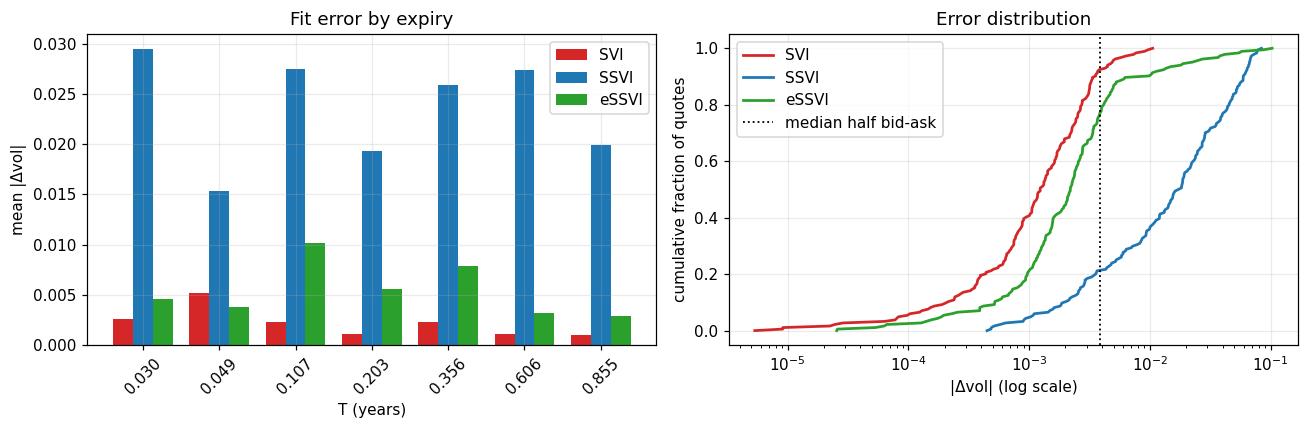

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

width = 0.26
for i, name in enumerate(SURFACES):
    per_expiry = [errors[name][np.abs(T - t) < 1e-12].mean() for t in EXPIRIES]
    ax[0].bar(np.arange(len(EXPIRIES)) + (i - 1) * width, per_expiry, width,
              label=name, color=PALETTE[name])
ax[0].set_xticks(np.arange(len(EXPIRIES)))
ax[0].set_xticklabels([f'{t:.3f}' for t in EXPIRIES], rotation=45)
ax[0].set_xlabel('T (years)'); ax[0].set_ylabel('mean |Δvol|')
ax[0].set_title('Fit error by expiry'); ax[0].legend()

for name in SURFACES:
    ax[1].plot(np.sort(errors[name]), np.linspace(0, 1, len(errors[name])),
               label=name, color=PALETTE[name], lw=1.8)
ax[1].axvline(np.median(HALF_SPREAD_VOL), color='k', ls=':', lw=1.2,
              label='median half bid-ask')
ax[1].set_xscale('log'); ax[1].set_xlabel('|Δvol| (log scale)')
ax[1].set_ylabel('cumulative fraction of quotes')
ax[1].set_title('Error distribution'); ax[1].legend()
plt.tight_layout(); plt.show()

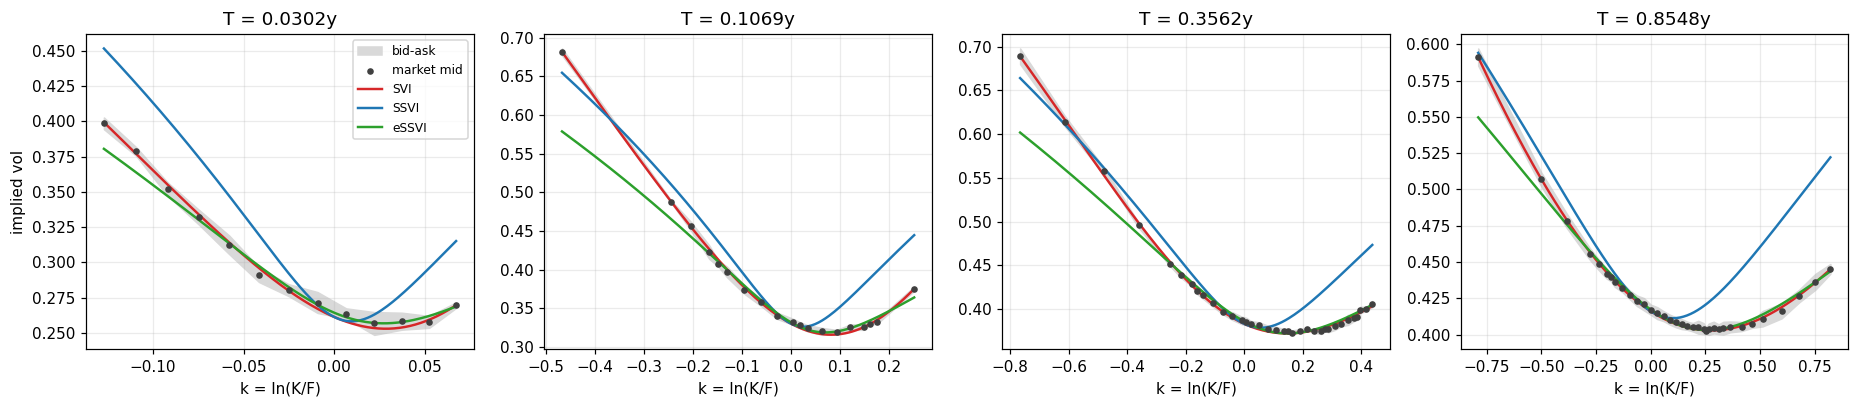

In [7]:
# smiles at four expiries, model vs market, with the bid-ask band the fit has to land in
show = EXPIRIES[np.linspace(0, len(EXPIRIES) - 1, 4).astype(int)]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=False)

for ax, t in zip(axes, show):
    m = np.abs(T - t) < 1e-12
    order = np.argsort(k[m])
    kk, vv, ss = k[m][order], MKT[m][order], HALF_SPREAD_VOL[m][order]
    ax.fill_between(kk, vv - ss, vv + ss, color='0.85', label='bid-ask')
    ax.scatter(kk, vv, s=11, color=PALETTE['market'], zorder=3, label='market mid')

    kg = np.linspace(kk.min(), kk.max(), 200)
    for name, s in SURFACES.items():
        ax.plot(kg, model_iv(s, forward_at(s, t) * np.exp(kg), t),
                color=PALETTE[name], lw=1.6, label=name)
    ax.set_title(f'T = {t:.4f}y'); ax.set_xlabel('k = ln(K/F)')
axes[0].set_ylabel('implied vol'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3 — Arbitrage

The decisive comparison. Two passes:

1. **Exact, at the fitted expiries** — `arbitrage.py`'s closed-form checkers, the same ones
   the rest of the codebase gates on.
2. **Numerical, off the pillars** — `g(k)` by finite differences and `∂w/∂t` by successive
   differences, on a dense grid of maturities that mostly falls *between* fitted expiries.
   This probes each model only through `implied_vol(K, T)`, so all three are tested
   identically and interpolation is included in what is being judged.

In [8]:
print('EXACT per-slice butterfly + pairwise calendar at the fitted expiries')
print('(raw SVI only — SSVI and eSSVI have no independent per-expiry SVI parameters)\n')

bad = 0
for t, p in zip(svi_surface.maturities, svi_surface.params):
    try:
        arb.check_butterfly(p)
        print(f'  T={t:.4f}  butterfly ok')
    except arb.ArbitrageError as exc:
        bad += 1
        print(f'  T={t:.4f}  BUTTERFLY FAIL — {str(exc).split(" for SVI")[0]}')

try:
    arb.check_calendar(list(zip(svi_surface.maturities, svi_surface.params)))
    print('\n  pairwise calendar: ok')
except arb.ArbitrageError as exc:
    print(f'\n  pairwise calendar: FAIL — {exc}')

print(f'\n=> {bad}/{len(svi_surface.maturities)} independently-fitted SVI slices '
      f'are butterfly-arbitrageable.')

EXACT per-slice butterfly + pairwise calendar at the fitted expiries
(raw SVI only — SSVI and eSSVI have no independent per-expiry SVI parameters)

  T=0.0302  butterfly ok
  T=0.0493  butterfly ok
  T=0.1069  BUTTERFLY FAIL — butterfly arbitrage: g(k=1.1300) = -2.396e-02 < 0 (negative implied density)
  T=0.2028  butterfly ok
  T=0.3562  butterfly ok
  T=0.6055  butterfly ok
  T=0.8548  BUTTERFLY FAIL — butterfly arbitrage: g(k=-3.2700) = -3.774e-02 < 0 (negative implied density)

  pairwise calendar: FAIL — calendar arbitrage between T=0.1069 and T=0.2028: total variance drops by 8.597e-01 at k=5.0000

=> 2/7 independently-fitted SVI slices are butterfly-arbitrageable.


These are not finite-difference artifacts — they are the exact closed-form checks, on the
parameters the optimizer actually returned. Nothing in a per-slice SVI fit prevents this:
each expiry is fitted alone, so neither the density's positivity nor the ordering against
the neighbouring expiry enters the objective.

The grid below spans `|k| <= 2.5`, wider than the quoted strikes. That is deliberate: the
exact checks above located violations at `k = 1.85`, `-2.32` and `-3.28`, out in the wings
where no quote constrains the fit. Restricting the check to the quoted range would hide
exactly the region where an unconstrained fit misbehaves — and a surface still has to
return a sane number there, because that is where a market maker gets asked for a price on
something illiquid. The quoted range is marked on the plots.

In [9]:
K_GRID = np.linspace(-2.5, 2.5, 501)
T_GRID = np.linspace(EXPIRIES[0], EXPIRIES[-1], 150)
K_QUOTED = (k.min(), k.max())

report, W_ALL, G_ALL = [], {}, {}
for name, s in SURFACES.items():
    W = np.array([total_variance(s, K_GRID, t) for t in T_GRID])
    G = np.array([g_numerical(K_GRID, w) for w in W])
    dW = np.diff(W, axis=0)
    W_ALL[name], G_ALL[name] = W, G
    report.append({
        'model': name,
        'min g(k)': G.min(),
        'butterfly viol %': 100 * np.mean(G < arb.BUTTERFLY_TOL),
        'min ∂w/∂t': dW.min(),
        'calendar viol %': 100 * np.mean(dW < arb.CALENDAR_TOL),
    })

pd.DataFrame(report).set_index('model').style.format({
    'min g(k)': '{:.3e}', 'min ∂w/∂t': '{:.3e}',
    'butterfly viol %': '{:.2f}%', 'calendar viol %': '{:.2f}%'})

,min g(k),butterfly viol %,min ∂w/∂t,calendar viol %
model,,,,
SVI,-6.064e-02,3.28%,-9.014e-02,4.78%
SSVI,2.524e-01,0.00%,4.609e-04,0.00%
eSSVI,2.594e-01,0.00%,4.055e-04,0.00%


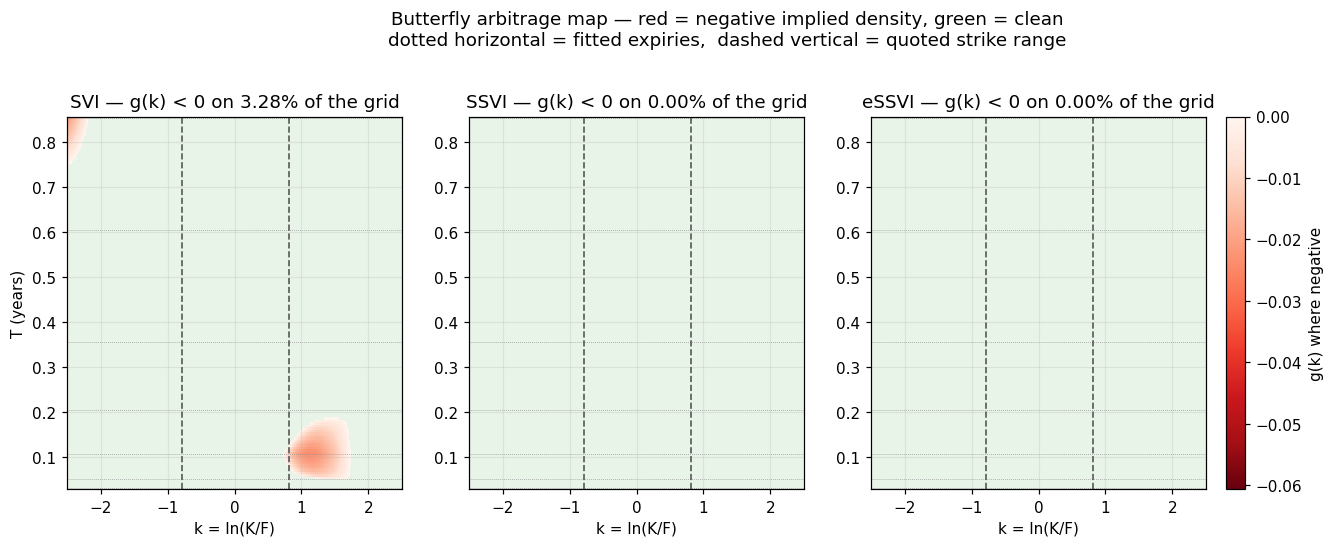

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
# scale the colour to the violations themselves, not to the (much larger) positive
# values of g -- otherwise a real -0.08 breach renders as almost white
worst = min(G_ALL[n].min() for n in SURFACES)

for ax, name in zip(axes, SURFACES):
    G = G_ALL[name]
    ax.set_facecolor('#e9f4e9')
    im = ax.pcolormesh(K_GRID, T_GRID, np.ma.masked_greater_equal(G, arb.BUTTERFLY_TOL),
                       cmap='Reds_r', vmin=worst, vmax=0, shading='auto')
    for t in EXPIRIES:
        ax.axhline(t, color='0.55', lw=0.5, ls=':')
    for kq in K_QUOTED:
        ax.axvline(kq, color='0.35', lw=1.1, ls='--')
    frac = 100 * np.mean(G < arb.BUTTERFLY_TOL)
    ax.set_title(f'{name} — g(k) < 0 on {frac:.2f}% of the grid')
    ax.set_xlabel('k = ln(K/F)')

axes[0].set_ylabel('T (years)')
fig.colorbar(im, ax=axes, label='g(k) where negative', pad=0.015)
plt.suptitle('Butterfly arbitrage map — red = negative implied density, green = clean\n'
             'dotted horizontal = fitted expiries,  dashed vertical = quoted strike range',
             y=1.10)
plt.show()

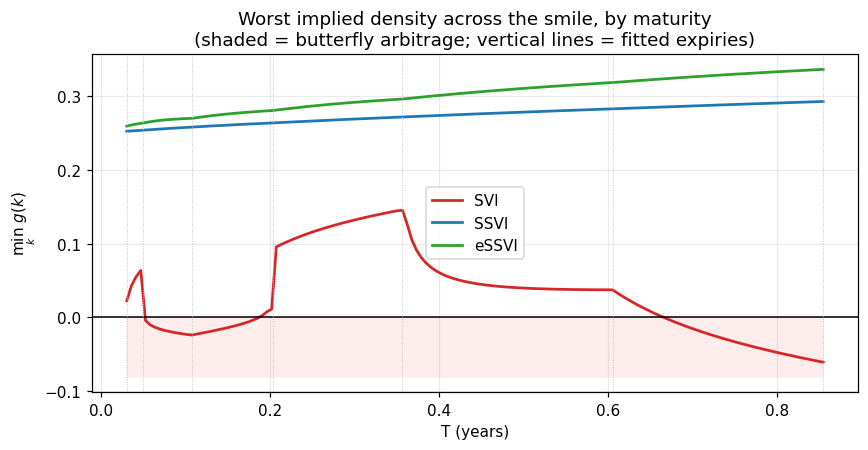

In [11]:
# the same information as a profile: how negative does the density get at each maturity
fig, ax = plt.subplots(figsize=(8, 4.2))
for name in SURFACES:
    ax.plot(T_GRID, G_ALL[name].min(axis=1), color=PALETTE[name], lw=1.8, label=name)
ax.axhline(0, color='k', lw=1)
ax.fill_between(T_GRID, ax.get_ylim()[0], 0, color='#fdecec', zorder=0)
for t in EXPIRIES:
    ax.axvline(t, color='0.75', lw=0.6, ls=':')
ax.set_xlabel('T (years)'); ax.set_ylabel(r'$\min_k\ g(k)$')
ax.set_title('Worst implied density across the smile, by maturity\n'
             '(shaded = butterfly arbitrage; vertical lines = fitted expiries)')
ax.legend(); plt.tight_layout(); plt.show()

## 4 — Where the SSVI constraint actually bites

SSVI's guarantee comes from holding **one ρ across the whole surface**. The natural guess
is that this costs it the ATM skew term structure — and on this chain that guess is
**wrong**, which is worth showing rather than glossing over.

The eSSVI ATM skew is exactly `∂w/∂k|₀ = ρψ`, so under SSVI (`ψ = θφ(θ)`) it becomes
`θ ρ φ(θ)`. Even with ρ frozen, `θφ(θ)` still varies with maturity, so a power-law `φ`
gives SSVI a perfectly reasonable skew term structure on its own.

In [12]:
rows = []
for t in EXPIRIES:
    m = np.abs(T - t) < 1e-12
    near = np.abs(k[m]) < 0.15
    mkt_skew = np.polyfit(k[m][near], (MKT[m][near] ** 2) * t, 1)[0] if near.sum() > 2 else np.nan

    p = svi_surface.params[int(np.argmin(np.abs(svi_surface.maturities - t)))]
    svi_skew = p.b * (p.rho - p.m / np.sqrt(p.m ** 2 + p.sigma ** 2))

    th = float(np.interp(t, ssvi_surface.maturities, ssvi_surface.theta_values))
    sp = ssvi_surface.ssvi_params
    ssvi_skew = th * sp.rho * sp.phi(th)

    sl = essvi_surface.slices[int(np.argmin(np.abs(essvi_surface.maturities - t)))]
    rows.append({'T': t, 'market': mkt_skew, 'SVI': svi_skew, 'SSVI': ssvi_skew,
                 'eSSVI': sl.rho * sl.psi, 'eSSVI ρ': sl.rho, 'SSVI ρ': sp.rho})

skew = pd.DataFrame(rows).set_index('T')
skew.style.format('{:.5f}')

,market,SVI,SSVI,eSSVI,eSSVI ρ,SSVI ρ
T,,,,,,
0.030166,-0.01381,-0.00880,-0.01010,-0.00864,-0.23653,-0.15231
0.049344,-0.02181,-0.01331,-0.01321,-0.01448,-0.29707,-0.15231
0.106879,-0.02209,-0.02389,-0.02187,-0.02558,-0.27578,-0.15231
0.202769,-0.03032,-0.03184,-0.03126,-0.03753,-0.27712,-0.15231
0.356194,-0.03971,-0.04165,-0.04275,-0.04986,-0.26425,-0.15231
0.605509,-0.05245,-0.05477,-0.05664,-0.06384,-0.26050,-0.15231
0.854824,-0.06535,-0.06949,-0.06798,-0.07636,-0.25784,-0.15231


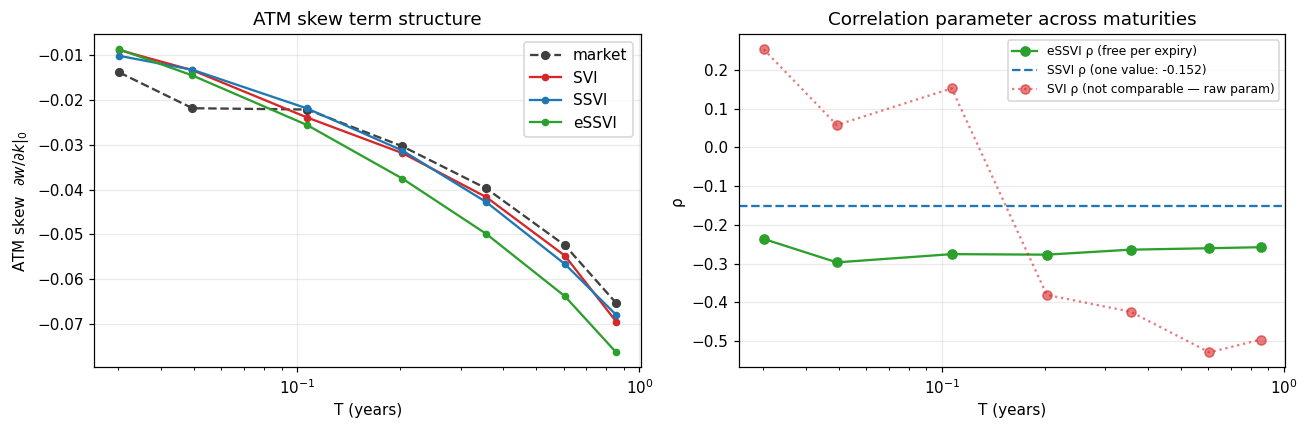

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(skew.index, skew['market'], 'o--', color=PALETTE['market'], label='market', ms=5)
for name in SURFACES:
    ax[0].plot(skew.index, skew[name], 'o-', color=PALETTE[name], label=name, ms=4)
ax[0].set_xscale('log'); ax[0].set_xlabel('T (years)')
ax[0].set_ylabel(r'ATM skew  $\partial w/\partial k|_0$')
ax[0].set_title('ATM skew term structure'); ax[0].legend()

ax[1].plot(essvi_surface.maturities, [s.rho for s in essvi_surface.slices],
           'o-', color=PALETTE['eSSVI'], label='eSSVI ρ (free per expiry)')
ax[1].axhline(ssvi_surface.ssvi_params.rho, color=PALETTE['SSVI'], ls='--',
              label=f'SSVI ρ (one value: {ssvi_surface.ssvi_params.rho:.3f})')
ax[1].plot(svi_surface.maturities, [p.rho for p in svi_surface.params], 'o:',
           color=PALETTE['SVI'], alpha=0.6, label='SVI ρ (not comparable — raw param)')
ax[1].set_xscale('log'); ax[1].set_xlabel('T (years)'); ax[1].set_ylabel('ρ')
ax[1].set_title('Correlation parameter across maturities'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Read the two panels together, because they say different things.

**Left:** all three models track the market's ATM skew closely, SSVI included. So the single
ρ is *not* what costs SSVI its fit — its skew term structure is fine. (eSSVI is marginally
the steepest at the long end: it is fitting prices across the whole smile, not the ATM
slope specifically, and trades a little skew accuracy for the wings.)

**Right:** the structural difference. SSVI is pinned to one horizontal line by construction.
eSSVI's ρ is free and settles on a real term structure, steepening from about −0.20 at the
front to −0.30 and staying there. SVI's ρ is a raw parameter and not directly comparable —
it is plotted only to show it swings from positive to −0.5 with no pattern, because nothing
couples one expiry to the next.

So where does SSVI actually lose? Not in the ATM slope but in **smile curvature and the
wings** — visible in the Section 2 smile plots, where SSVI's blue curve lifts away from the
quotes on both sides while matching the middle. One ρ plus one global shape function cannot
bend each expiry's smile independently. That is what the extra two parameters per expiry
buy, and it is worth roughly a 4× reduction in mean error here.

## 5 — Stress test: does the guarantee survive bad data?

One clean fit could be luck. Here the chain is resampled with multiplicative noise on the
quotes and all three models are refitted, counting how often each produces an arbitrageable
surface. This is where a guarantee that holds *by construction* separates from one that
holds when the data is well-behaved.

In [14]:
N_TRIALS, NOISE = 25, 0.03
rng = np.random.default_rng(20220401)

stress = {name: {'butterfly': 0, 'calendar': 0, 'failed_fit': 0} for name in SURFACES}
k_stress = np.linspace(-0.9, 0.9, 201)
t_stress = np.linspace(EXPIRIES[0], EXPIRIES[-1], 60)

for trial in range(N_TRIALS):
    noisy = chain.copy()
    bump = 1.0 + NOISE * rng.standard_normal(len(noisy))
    noisy['mid_iv'] = np.maximum(noisy['mid_iv'].to_numpy() * bump, 1e-4)
    noisy['mid'] = bs.price(F, K, T, 0.0, 0.0, noisy['mid_iv'].to_numpy(),
                            noisy['option_type'].to_numpy())

    fits = {}
    try:
        fits['SVI'] = surface.fit_surface(noisy, validate=False, check_interior=False)
    except Exception:
        stress['SVI']['failed_fit'] += 1
    try:
        fits['SSVI'] = surface.fit_ssvi_surface(noisy, validate=False)
    except Exception:
        stress['SSVI']['failed_fit'] += 1
    try:
        fits['eSSVI'] = ge.calibrate(**ge.chain_to_calibration_inputs(noisy)).surface
    except Exception:
        stress['eSSVI']['failed_fit'] += 1

    for name, s in fits.items():
        W = np.array([total_variance(s, k_stress, t) for t in t_stress])
        G = np.array([g_numerical(k_stress, w) for w in W])
        stress[name]['butterfly'] += int((G < arb.BUTTERFLY_TOL).any())
        stress[name]['calendar'] += int((np.diff(W, axis=0) < arb.CALENDAR_TOL).any())

stress_df = pd.DataFrame(stress).T
stress_df.columns = [f'{c} (of {N_TRIALS})' for c in stress_df.columns]
print(f'{N_TRIALS} refits with {NOISE:.0%} i.i.d. multiplicative noise on every quote\n')
stress_df

25 refits with 3% i.i.d. multiplicative noise on every quote



,butterfly (of 25),calendar (of 25),failed_fit (of 25)
SVI,23,25,0
SSVI,1,0,0
eSSVI,0,0,0


## 6 — Verdict

In [15]:
summary = pd.DataFrame({
    'params': [N_PARAMS[n] for n in SURFACES],
    'fit time (s)': [timings[n] for n in SURFACES],
    'mean |Δvol|': [errors[n].mean() for n in SURFACES],
    'inside bid-ask': [np.mean(errors[n] <= HALF_SPREAD_VOL) for n in SURFACES],
    'butterfly viol %': [100 * np.mean(G_ALL[n] < arb.BUTTERFLY_TOL) for n in SURFACES],
    'arbitrage-free trials': [f"{N_TRIALS - max(stress[n]['butterfly'], stress[n]['calendar'])}"
                              f"/{N_TRIALS}" for n in SURFACES],
    'guarantee': ['none (checked after)', 'global, one ρ', 'global, ρ per expiry'],
}, index=list(SURFACES))

summary.style.format({'fit time (s)': '{:.2f}', 'mean |Δvol|': '{:.3%}',
                      'inside bid-ask': '{:.1%}', 'butterfly viol %': '{:.2f}%'})

,params,fit time (s),mean |Δvol|,inside bid-ask,butterfly viol %,arbitrage-free trials,guarantee
SVI,35,0.32,0.175%,89.7%,3.28%,0/25,none (checked after)
SSVI,10,0.24,2.380%,22.7%,0.00%,24/25,"global, one ρ"
eSSVI,21,0.11,0.525%,77.8%,0.00%,25/25,"global, ρ per expiry"


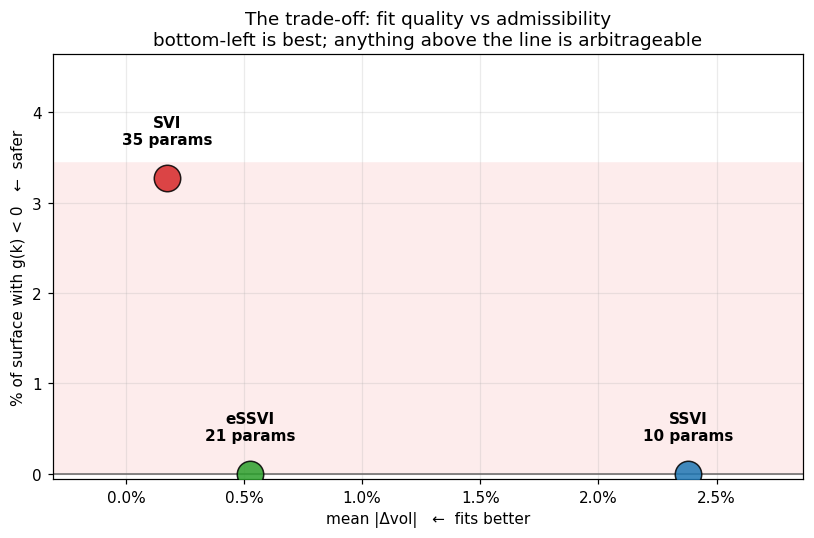

In [16]:
# fit quality against admissibility, which is the whole trade-off in one picture
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(7.5, 5))
for name in SURFACES:
    x = errors[name].mean()
    y = 100 * np.mean(G_ALL[name] < arb.BUTTERFLY_TOL)
    ax.scatter(x, y, s=300, color=PALETTE[name], edgecolor='k', zorder=3, alpha=0.85)
    ax.annotate(f'{name}\n{N_PARAMS[name]} params', (x, y),
                textcoords='offset points', xytext=(0, 22),
                ha='center', fontsize=10, fontweight='bold')

ax.axhspan(0, ax.get_ylim()[1], color='#fdecec', zorder=0)
ax.axhline(0, color='0.4', lw=1)
ax.margins(x=0.22, y=0.35)
ax.set_ylim(bottom=-0.06)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.1%}'))
ax.set_xlabel('mean |Δvol|   ←  fits better')
ax.set_ylabel('% of surface with g(k) < 0   ←  safer')
ax.set_title('The trade-off: fit quality vs admissibility\n'
             'bottom-left is best; anything above the line is arbitrageable')
plt.tight_layout(); plt.show()

### Reading the results

**raw SVI** fits best and is the only one of the three that produced arbitrage. With 5 free
parameters per expiry and no coupling between them it tracks each smile almost to the
bid-ask, but nothing in the objective prevents a negative density or a crossed pair of
expiries, and on this chain several slices do exactly that. Using it safely means checking
every fit and having a policy for the failures — the pipeline's default is to drop the
offending expiry, which trades the arbitrage for a hole in the surface.

**SSVI** cannot produce arbitrage but pays for it in fit: one ρ for every maturity is a
strong constraint, and it shows up as the worst error of the three by a wide margin, with
most quotes landing outside the bid-ask.

**Global eSSVI** is the compromise the paper is arguing for, and the numbers bear it out:
several times closer to the market than SSVI, within striking distance of unconstrained
SVI, and — like SSVI, unlike SVI — structurally unable to produce arbitrage, at any
maturity, including the interpolated and extrapolated regions where it was never fitted.

The asymmetry worth keeping in mind: SVI's fit advantage is a matter of degree and can be
narrowed, but its arbitrage exposure is a matter of kind. eSSVI's clean sweep of the stress
test is not a claim about this dataset — it is Proposition 3.1, and no chain, however
noisy, can move it.